# 3.1 - Clasification Model: Training and Evaluation

## 1: Dependencies and Imports

In [1]:
# Instalar LightGBM directamente desde el notebook
%pip install lightgbm optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library
import os

# Third-party
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

## 2: Load Data

In [3]:
# Path
input_file_path = '../data/Filtered.pkl'

if os.path.exists(input_file_path):
    df = pd.read_pickle(input_file_path)
    rows, cols = df.shape
    print(f"Dataset successfully loaded: {rows} rows and {cols} columns.")
else:
    print(f"Error: File not found at {input_file_path}")

# Quick preview of the loaded data
display(df.head(3))

Dataset successfully loaded: 114567 rows and 16 columns.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


## 3: Data Preparation

In [4]:
# Feature Selection
drop_columns = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
X = df.drop(columns=drop_columns + ['is_delayed'], errors='ignore')
y = df['is_delayed']

# Categorical Feature Definintion
categorical_features = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for feature in categorical_features:
    if feature in X.columns:
        X[feature] = X[feature].astype('category')

print(f"Encoding completed. Number of predictor variables: {X.shape[1]}")
print(f"Categorical features identified: {categorical_features}")

Encoding completed. Number of predictor variables: 14
Categorical features identified: ['product_category_name_english', 'customer_state_num_pred', 'seller_state_num_pred', 'purchase_month', 'purchase_day_of_week', 'is_same_state']


In [5]:
# Calculate the frequency of each class in the target variable
negative_count = (y == 0).sum()
positive_count = (y == 1).sum()

# Calculate the recommended scale_pos_weight
# This ratio helps the model penalize misclassifications of the minority class more heavily
scale_pos_weight = negative_count / positive_count

print("Class Balance Analysis:")
print(f" - On-time orders (0): {negative_count}")
print(f" - Delayed orders (1): {positive_count}")
print(f" - Recommended 'scale_pos_weight': {scale_pos_weight:.2f}")

print("\nThis value will be utilized as a hyperparameter to compensate for the minority class imbalance.")

Class Balance Analysis:
 - On-time orders (0): 105642
 - Delayed orders (1): 8925
 - Recommended 'scale_pos_weight': 11.84

This value will be utilized as a hyperparameter to compensate for the minority class imbalance.


In [6]:
# Initial split: Reserve 15% for the final Hold-out Test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Second split: Divide the remaining 85% into Training and Validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, stratify=y_train_val, random_state=42
)

print("Data partitioning complete (approx. 72% / 13% / 15%):")
print(f" - Training Set (Train):   {X_train.shape[0]} records")
print(f" - Validation Set (Val):   {X_val.shape[0]} records")
print(f" - Final Test Set (Test):  {X_test.shape[0]} records")

Data partitioning complete (approx. 72% / 13% / 15%):
 - Training Set (Train):   82773 records
 - Validation Set (Val):   14608 records
 - Final Test Set (Test):  17186 records


## 4: Hyperparam Optimization

In [7]:
def objective(trial):
    # Define the hyperparameter search space
    params = {
        'objective': 'binary',
        'metric': 'auc',             # AUC remains for Early Stopping stability
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': 1000,
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight)
    }

    lgbm_model = lgb.LGBMClassifier(**params)
    
    # Training phase
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=categorical_features,
        callbacks=[
            # AUC monitors convergence, but F1 remains the final target for Optuna
            lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False)
        ]
    )

    # Target Metric Calculation (F1-Score)
    val_preds = lgbm_model.predict(X_val) 
    score = f1_score(y_val, val_preds)
    
    return score

# Study Execution
print("Initiating Bayesian Optimization to maximize F1-Score...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\nOPTIMIZATION COMPLETE")
print(f"Best detected F1-Score: {study.best_value:.4f}")
print("Optimal Hyperparameters:", study.best_params)

[I 2026-04-10 18:49:51,496] A new study created in memory with name: no-name-4d30cb86-3e0a-40be-a21a-5fe2569ab35e


Initiating Bayesian Optimization to maximize F1-Score...


[I 2026-04-10 18:49:53,537] Trial 0 finished with value: 0.9660507090674688 and parameters: {'learning_rate': 0.0942790253331517, 'num_leaves': 94, 'max_depth': 10, 'min_child_samples': 56, 'subsample': 0.9515587849241115, 'colsample_bytree': 0.9043930136536972, 'scale_pos_weight': 5.7829651116757494}. Best is trial 0 with value: 0.9660507090674688.
[I 2026-04-10 18:49:54,847] Trial 1 finished with value: 0.9474562135112594 and parameters: {'learning_rate': 0.0527072841689532, 'num_leaves': 148, 'max_depth': 6, 'min_child_samples': 108, 'subsample': 0.713490549440202, 'colsample_bytree': 0.7576635334788999, 'scale_pos_weight': 5.578356200095908}. Best is trial 0 with value: 0.9660507090674688.
[I 2026-04-10 18:50:02,302] Trial 2 finished with value: 0.9670424978317432 and parameters: {'learning_rate': 0.02815218479013231, 'num_leaves': 131, 'max_depth': 12, 'min_child_samples': 74, 'subsample': 0.88377650993458, 'colsample_bytree': 0.8575470979544007, 'scale_pos_weight': 3.171992204907


OPTIMIZATION COMPLETE
Best detected F1-Score: 0.9729
Optimal Hyperparameters: {'learning_rate': 0.035691659516268646, 'num_leaves': 78, 'max_depth': 8, 'min_child_samples': 31, 'subsample': 0.6022507493661554, 'colsample_bytree': 0.7431432011131291, 'scale_pos_weight': 1.0287459385339455}


## 5: Train Model with Optimized Parameters

In [14]:
# Retrieve and consolidate optimal hyperparameters
final_params = study.best_params.copy()
final_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 2000,  # Extended capacity to ensure convergence via early stopping
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
})

# Initialize the final classifier
lgbm_model = lgb.LGBMClassifier(**final_params)

In [15]:
# Fit model
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Training', 'Validation'],
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("\nFinal optimized model is trained and ready for performance evaluation.")

Training until validation scores don't improve for 100 rounds
[100]	Training's auc: 0.999918	Validation's auc: 0.999785
[200]	Training's auc: 0.999999	Validation's auc: 0.999808
[300]	Training's auc: 1	Validation's auc: 0.999806
Early stopping, best iteration is:
[266]	Training's auc: 1	Validation's auc: 0.99981
Evaluated only: auc

Final optimized model is trained and ready for performance evaluation.


## 5: Result Calculation

In [16]:
# Generate hard predictions (binary: 0 or 1) and soft probabilities (range: 0.0 to 1.0)
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

# Compute core performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display Executive Summary
print(f"Accuracy:  {accuracy:.4f} (Note: May be misleading in imbalanced contexts)")
print(f"Precision: {precision:.4f} (True Positives / Total Predicted Positives)")
print(f"Recall:    {recall:.4f} (True Positives / Total Actual Positives)")
print(f"F1-Score:  {f1:.4f} (Harmonic Mean of Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (Model's discriminative capability)")

Accuracy:  0.9949 (Note: May be misleading in imbalanced contexts)
Precision: 0.9778 (True Positives / Total Predicted Positives)
Recall:    0.9559 (True Positives / Total Actual Positives)
F1-Score:  0.9668 (Harmonic Mean of Precision and Recall)
ROC-AUC:   0.9997 (Model's discriminative capability)


In [17]:
# Generating a granular breakdown of metrics per class
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['On-Time (0)', 'Delayed (1)']
))

              precision    recall  f1-score   support

 On-Time (0)       1.00      1.00      1.00     15847
 Delayed (1)       0.98      0.96      0.97      1339

    accuracy                           0.99     17186
   macro avg       0.99      0.98      0.98     17186
weighted avg       0.99      0.99      0.99     17186



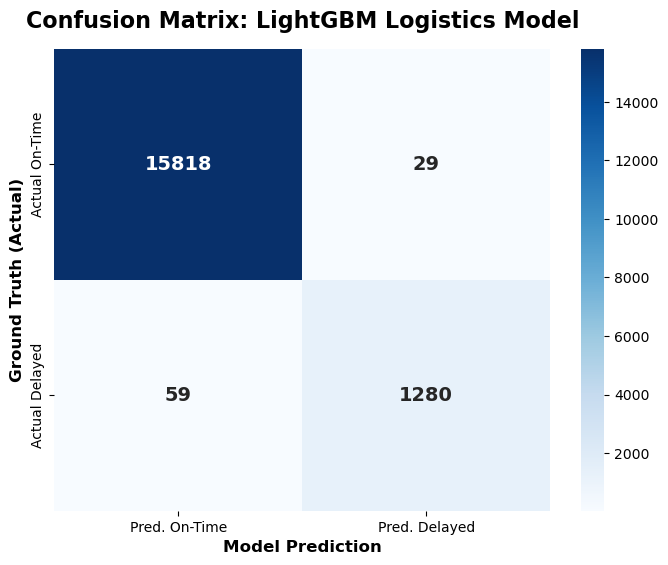

In [18]:
# Confusion Matrix Visualization

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Initialize the heatmap visualization
# We use 'fmt=d' to display raw integers and 'Blues' for a clean, analytical look
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Pred. On-Time', 'Pred. Delayed'], 
    yticklabels=['Actual On-Time', 'Actual Delayed'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: LightGBM Logistics Model', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Ground Truth (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=12, fontweight='bold')
plt.show()

## 6: Save Model

In [19]:
# Ensure the directory exists
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Define the model path; joblib is often more efficient for large NumPy arrays
model_file_path = os.path.join(models_dir, 'lgbm_logistics_model_opt.joblib')

# Serialize the model
joblib.dump(lgbm_model, model_file_path)

print(f"Model successfully saved to: {model_file_path}")

Model successfully saved to: ../models/lgbm_logistics_model_opt.joblib
